In [1]:
using PyPlot
using JLD2
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful
using Interpolations
using LsqFit

In [2]:
pathdir_stripe_90 = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°

N = 30
λ = 421e-9
γ = 32.7e6 # In Hz
Γ = 2.02e8 # In Hz

ω0 = 2π*ustrip(c_0)/λ

Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2) # In photon/m^2/atom

factor_ellipse = 2
size_pxl = 0.1966e-6; # New pxl size since 2025/12/31

### Load experimental data

In [3]:
# Stripe 90
@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" Amplitude_laser τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/Stripes_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" centers_stripes_ds major_axis_stripes_ds minor_axis_stripes_ds nbr_stripes_ds
@load "Saved_exp_data/Nbr_atoms_per_stripe_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" Nbr_atoms_per_stripe
@load "Saved_exp_data/Intensity_integrated_stripes_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" Iatoms_stripes Ibkg_stripes Idark_stripes Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms
Iatoms_stripe_90, Ibkg_stripe_90, Idark_stripe_90, Mean_atoms_stripe_90, Mean_bkg_stripe_90, Mean_dark_stripe_90, Mean_bkg_atoms_stripe_90, Std_atoms_stripe_90, Std_bkg_stripe_90, Std_dark_stripe_90, Std_bkg_atoms_stripe_90 = Iatoms_stripes, Ibkg_stripes, Idark_stripes, Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms, Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms
Ntot = 185491; # Total atom nbr

### Fit the experimental saturation parameter

In [4]:
I_elec_measured = [0.1:0.1:1;]
P_measured = [0.004, 0.035, 0.15, 0.43, 0.9, 1.5, 2.1, 2.6, 3, 3.4] * 1e-3
w0 = 300.0750022524122e-6 # Fitted waist
sat_measured = 2 .* P_measured ./ (π*w0^2 * Isat * ustrip(ħ * ω0))
interp_linear = linear_interpolation(I_elec_measured, sat_measured);

In [5]:
linear(x, p) = p[1] .* x
p0 = [2.]
fit = curve_fit(linear, reshape(mean(Ibkg_stripe_90/Isat, dims=2), length(unique(Amplitude_laser))), interp_linear(unique(Amplitude_laser)), p0)
factor_sat = fit.param[1];

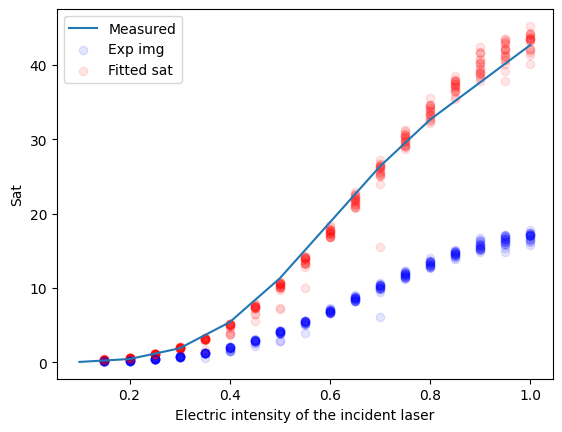

In [6]:
plot(I_elec_measured, sat_measured, label="Measured")

for i = 1:size(Ibkg_stripe_90)[1]
    for j = 1:size(Ibkg_stripe_90)[2]
        if Ibkg_stripe_90[i, j] > 0
            scatter(Amplitude_laser[(i-1)*size(Ibkg_stripe_90)[2]+j], Ibkg_stripe_90[i, j]/Isat, color="b", alpha=0.1)
            scatter(Amplitude_laser[(i-1)*size(Ibkg_stripe_90)[2]+j], (Ibkg_stripe_90[i, j]/Isat) * factor_sat, color="r", alpha=0.1)
        end
    end
end
legend(["Measured", "Exp img", "Fitted sat"])
xlabel("Electric intensity of the incident laser")
ylabel("Sat");

### For the simulations, gets the $I_{tot}$ per stripe, taking into account the nbr of atoms in each stripe

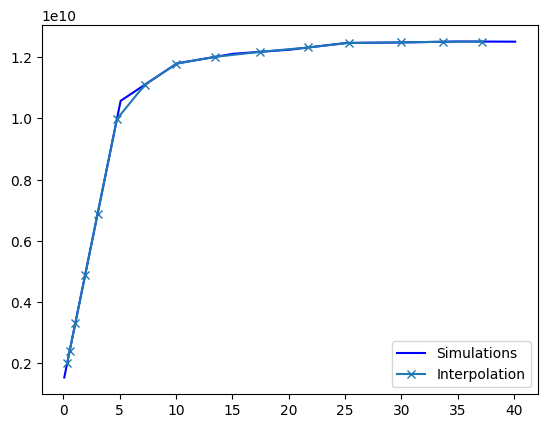

PyObject <matplotlib.legend.Legend object at 0x0000025C8F0F9D10>

In [7]:
# Interpolate the simulations
@load "Solutions_sim/Itot_N_30_Sat_0.1to40.1_n0_53.12_decay_rate_up_down.jdl2"  sat sat_computed n_list Itot_stripe I_SE_SR_SS_stripe I_SR_SR_SS_stripe nbr_error_N

interp_linear_sim = linear_interpolation(sat_computed, reshape(Itot_stripe, length(Itot_stripe)))

idx_lb = 2
idx_hb = 16

plot(sat_computed, Itot_stripe, label="Simulations", color="b")
plot(factor_sat * Mean_bkg_stripe_90[idx_lb:idx_hb]/Isat, [interp_linear_sim(factor_sat * Mean_bkg/Isat) for Mean_bkg in Mean_bkg_stripe_90[idx_lb:idx_hb]], label="Interpolation", marker="x")

legend()

In [8]:
# Compute the simulated intensity for each image
I_sim = zeros((idx_hb-idx_lb+1, size(Ibkg_stripes)[2]))

for i = idx_lb:idx_hb
    for j = 1:size(Ibkg_stripes)[2]
        if nbr_stripes_ds[i, j] > 0
            for k in 1:Int(nbr_stripes_ds[i, j])
                S_stripe = π * (major_axis_stripes_ds[i][j][k]/factor_ellipse) * (minor_axis_stripes_ds[i][j][k]/factor_ellipse) * size_pxl^2
                if S_stripe > 0
                    I_sim[i-idx_lb+1, j] += (Nbr_atoms_per_stripe[i, j, k]/(N*length(n_list)*S_stripe)) * interp_linear_sim(factor_sat * Ibkg_stripe_90[i, j]/Isat)
                end
            end
        end
    end
end

### Plot as a function of Sat measured from the images bkg

In [ ]:
close("all")
fig = subplots()
title("Bkg-atoms")


# Stripes 90°
line_stripe_90, = errorbar(factor_sat * Mean_bkg_stripe_90/Isat, Mean_bkg_atoms_stripe_90, yerr=Std_bkg_atoms_stripe_90, label="Stripes 90°")

for i = 1:size(Iatoms_stripe_90)[1]
    for j = 1:size(Iatoms_stripe_90)[2]
        scatter(factor_sat * Ibkg_stripe_90[i, j]/Isat, Ibkg_stripe_90[i, j]-Iatoms_stripe_90[i, j], color=line_stripe_90.get_color(), alpha = 0.1)
    end
end


# # Simulations
factor_sim_data = (1-0.16) # Amount of light that will not enter in the camera
line_sim, = errorbar(factor_sat * Mean_bkg_stripe_90[idx_lb:idx_hb]/Isat, reshape(mean(I_sim, dims=2), size(I_sim)[1]), yerr=reshape(std(I_sim, dims=2), size(I_sim)[1]), label="simulations")

for i = 1:size(I_sim)[1]
    for j = 1:size(I_sim)[2]
        scatter(factor_sat * Ibkg_stripe_90[i+idx_lb-1, j]/Isat, I_sim[i, j], color=line_sim.get_color(), alpha = 0.1)
    end
end


xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

### Select stipe with a lot of atoms

In [ ]:
for i in 1:size(Iatoms_stripe_90)[1]
    for j in 1:size(Iatoms_stripe_90)[2]
        for k in 1:Int(nbr_stripes_ds[i, j])
            scatter(factor_sat * Ibkg_stripe_90[i, j]/Isat, Nbr_atoms_per_stripe[i, j, k], color="b")
        end
    end
end

Nbr_atoms_boundary_lb = 500
Sat_atoms_boundary_lb = 3

axhline(Nbr_atoms_boundary_lb, color="r")
axvline(Sat_atoms_boundary_lb, color="r")

xlabel(L"Idx of $I_{laser}$")
ylabel(L"s")

In [ ]:
# Compute the simulated intensity for each image
idx_lb_atom_nbr = 6
I_sim_select = zeros((idx_hb-idx_lb_atom_nbr+1, size(Ibkg_stripes)[2]))

for i = idx_lb_atom_nbr:idx_hb
    for j = 1:size(Ibkg_stripes)[2]
        if nbr_stripes_ds[i, j] > 0
            for k in 1:Int(nbr_stripes_ds[i, j])
                if Nbr_atoms_per_stripe[i, j, k] > Nbr_atoms_boundary_lb
                    S_stripe = π * (major_axis_stripes_ds[i][j][k]/factor_ellipse) * (minor_axis_stripes_ds[i][j][k]/factor_ellipse) * size_pxl^2
                    if S_stripe > 0
                        I_sim_select[i-idx_lb_atom_nbr+1, j] += (Nbr_atoms_per_stripe[i, j, k]/(N*length(n_list)*S_stripe)) * interp_linear_sim(factor_sat * Ibkg_stripe_90[i, j]/Isat)
                    end
                end
            end
        end
    end
end

In [ ]:

### Plot as a function of Sat measured from the images bkg
close("all")
fig = subplots()
title("Bkg-atoms")


# Stripes 90°
line_stripe_90, = errorbar(factor_sat * Mean_bkg_stripe_90/Isat, Mean_bkg_atoms_stripe_90, yerr=Std_bkg_atoms_stripe_90, label="Stripes 90°")

for i = 1:size(Iatoms_stripe_90)[1]
    for j = 1:size(Iatoms_stripe_90)[2]
        scatter(factor_sat * Ibkg_stripe_90[i, j]/Isat, Ibkg_stripe_90[i, j]-Iatoms_stripe_90[i, j], color=line_stripe_90.get_color(), alpha = 0.1)
    end
end


# # Simulations
factor_sim_data = (1-0.16) # Amount of light that will not enter in the camera
line_sim, = errorbar(factor_sat * Mean_bkg_stripe_90[idx_lb_atom_nbr:idx_hb]/Isat, reshape(factor_sim_data * mean(I_sim_select, dims=2), size(I_sim_select)[1]), yerr=reshape(factor_sim_data * std(I_sim_select, dims=2), size(I_sim_select)[1]), label="simulations")

for i = 1:size(I_sim_select)[1]
    for j = 1:size(I_sim_select)[2]
        scatter(factor_sat * Ibkg_stripe_90[i+idx_lb_atom_nbr-1, j]/Isat, I_sim_select[i, j], color=line_sim.get_color(), alpha = 0.1)
    end
end


xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

### Compare with SE

In [9]:
function decay_atoms_indep_V3(sat)
    return 1/2 .* 1 ./ (1 .+ 1 ./sat)
end

decay_atoms_indep_V3 (generic function with 1 method)

In [ ]:
# Compute the simulated intensity for each image
I_SE = zeros(size(Ibkg_stripes)[1:2])

for i = 1:size(Ibkg_stripes)[1]
    for j = 1:size(Ibkg_stripes)[2]
        if nbr_stripes_ds[i, j] > 0
            for k in 1:Int(nbr_stripes_ds[i, j])
                S_stripe = π * (major_axis_stripes_ds[i][j][k]/factor_ellipse) * (minor_axis_stripes_ds[i][j][k]/factor_ellipse) * size_pxl^2
                if S_stripe > 0
                    I_SE[i, j] += (Nbr_atoms_per_stripe[i, j, k]/S_stripe) * decay_atoms_indep_V3(factor_sat * Ibkg_stripe_90[i, j]/Isat) * γ
                end
            end
        end
    end
end

In [ ]:
close("all")
fig = subplots()
rc("font", size=12)

# Stripes 90°
line_stripe_90, = errorbar(factor_sat * Mean_bkg_stripe_90/Isat, Mean_bkg_atoms_stripe_90, yerr=Std_bkg_atoms_stripe_90, label="Experimental data")

for i = 1:size(Iatoms_stripe_90)[1]
    for j = 1:size(Iatoms_stripe_90)[2]
        scatter(factor_sat * Ibkg_stripe_90[i, j]/Isat, Ibkg_stripe_90[i, j]-Iatoms_stripe_90[i, j], color=line_stripe_90.get_color(), alpha = 0.1)
    end
end


# # Simulations
factor_sim_data = (1-0.16) # Amount of light that will not enter in the camera
line_sim, = errorbar(factor_sat * Mean_bkg_stripe_90[idx_lb:idx_hb]/Isat, reshape(factor_sim_data * mean(I_sim, dims=2), size(I_sim)[1]), yerr=reshape(factor_sim_data * std(I_sim, dims=2), size(I_sim)[1]), label="Simulations")

for i = 1:size(I_sim)[1]
    for j = 1:size(I_sim)[2]
        scatter(factor_sat * Ibkg_stripe_90[i+idx_lb-1, j]/Isat, I_sim[i, j], color=line_sim.get_color(), alpha = 0.1)
    end
end

# SE
factor_sim_data = (1-0.16) # Amount of light that will not enter in the camera
line_SE, = errorbar(factor_sat * Mean_bkg_stripe_90/Isat, reshape(factor_sim_data * mean(I_SE, dims=2), size(I_SE)[1]), yerr=reshape(factor_sim_data * std(I_SE, dims=2), size(I_SE)[1]), label="SE", color="r", linestyle="--")

for i = 1:size(I_SE)[1]
    for j = 1:size(I_SE)[2]
        scatter(factor_sat * Ibkg_stripe_90[i, j]/Isat, I_SE[i, j], color=line_SE.get_color(), alpha = 0.1)
    end
end


xlabel(L"s", fontsize=12)
ylabel(L"I_{Stripe}", fontsize=12)

legend()

savefig("Final_result.pdf")

# pygui(true); show();
pygui(false);

### Add higher density

In [29]:
# Interpolate the simulations
@load "Solutions_sim/Itot_N_30_Sat_0.1to40.1_n0_531.24_decay_rate_up_down.jdl2"  sat sat_computed n_list Itot_stripe I_SE_SR_SS_stripe I_SR_SR_SS_stripe nbr_error_N
sat_computed_low_s, Itot_stripe_low_s = sat_computed, Itot_stripe

@load "Solutions_sim/Itot_N_30_Sat_20.1to40.1_n0_531.24_decay_rate_up_down.jdl2"  sat sat_computed n_list Itot_stripe I_SE_SR_SS_stripe I_SR_SR_SS_stripe nbr_error_N
sat_computed, Itot_stripe = vcat(sat_computed_low_s, sat), vcat(Itot_stripe_low_s, Itot_stripe)

([0.1, 5.1, 10.1, 15.1, 20.1, 25.1, 30.1, 35.1, 40.1], [5.78270685182166e8; 7.666621331546392e9; … ; 1.1068725961403624e10; 1.1167238139992004e10;;])

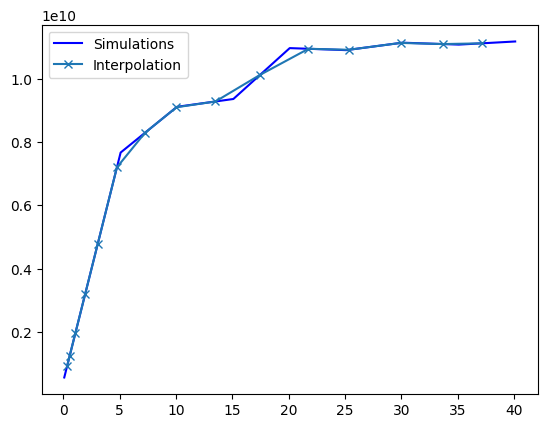

PyObject <matplotlib.legend.Legend object at 0x0000025CA5E6D1D0>

In [40]:
interp_linear_sim_higher_n = linear_interpolation(sat_computed, reshape(Itot_stripe, length(Itot_stripe)))

idx_lb_higher_n = 2
idx_hb_higher_n = length(Mean_bkg_stripe_90)-3

plot(sat_computed, Itot_stripe, label="Simulations", color="b")
plot(factor_sat * Mean_bkg_stripe_90[idx_lb_higher_n:idx_hb_higher_n]/Isat, [interp_linear_sim_higher_n(factor_sat * Mean_bkg/Isat) for Mean_bkg in Mean_bkg_stripe_90[idx_lb_higher_n:idx_hb_higher_n]], label="Interpolation", marker="x")

legend()

In [41]:
# Compute the simulated intensity for each image
I_sim_higher_n = zeros((idx_hb_higher_n-idx_lb_higher_n+1, size(Ibkg_stripes)[2]))

for i = idx_lb_higher_n:idx_hb_higher_n
    for j = 1:size(Ibkg_stripes)[2]
        if nbr_stripes_ds[i, j] > 0
            for k in 1:Int(nbr_stripes_ds[i, j])
                S_stripe = π * (major_axis_stripes_ds[i][j][k]/factor_ellipse) * (minor_axis_stripes_ds[i][j][k]/factor_ellipse) * size_pxl^2
                if S_stripe > 0
                    I_sim_higher_n[i-idx_lb_higher_n+1, j] += (Nbr_atoms_per_stripe[i, j, k]/(N*length(n_list)*S_stripe)) * interp_linear_sim_higher_n(factor_sat * Ibkg_stripe_90[i, j]/Isat)
                end
            end
        end
    end
end

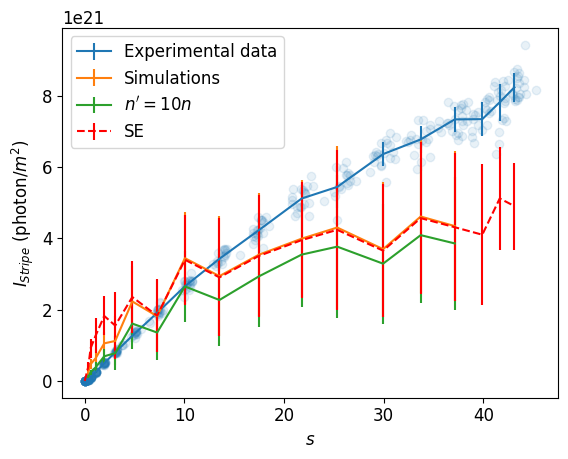

In [50]:
close("all")
fig = subplots()
rc("font", size=12)

# Stripes 90°
line_stripe_90, = errorbar(factor_sat * Mean_bkg_stripe_90/Isat, Mean_bkg_atoms_stripe_90, yerr=Std_bkg_atoms_stripe_90, label="Experimental data")

for i = 1:size(Iatoms_stripe_90)[1]
    for j = 1:size(Iatoms_stripe_90)[2]
        scatter(factor_sat * Ibkg_stripe_90[i, j]/Isat, Ibkg_stripe_90[i, j]-Iatoms_stripe_90[i, j], color=line_stripe_90.get_color(), alpha = 0.1)
    end
end


# # Simulations
factor_sim_data = (1-0.16) # Amount of light that will not enter in the camera
line_sim, = errorbar(factor_sat * Mean_bkg_stripe_90[idx_lb:idx_hb]/Isat, reshape(factor_sim_data * mean(I_sim, dims=2), size(I_sim)[1]), yerr=reshape(factor_sim_data * std(I_sim, dims=2), size(I_sim)[1]), label="Simulations")

# for i = 1:size(I_sim)[1]
#     for j = 1:size(I_sim)[2]
#         scatter(factor_sat * Ibkg_stripe_90[i+idx_lb-1, j]/Isat, I_sim[i, j], color=line_sim.get_color(), alpha = 0.1)
#     end
# end

# # Simulations higher n
factor_sim_data = (1-0.16) # Amount of light that will not enter in the camera
line_sim_higher_n, = errorbar(factor_sat * Mean_bkg_stripe_90[idx_lb_higher_n:idx_hb_higher_n]/Isat, reshape(factor_sim_data * mean(I_sim_higher_n, dims=2), size(I_sim_higher_n)[1]), yerr=reshape(factor_sim_data * std(I_sim_higher_n, dims=2), size(I_sim_higher_n)[1]), label=L"n'=10n")

# for i = 1:size(I_sim_higher_n)[1]
#     for j = 1:size(I_sim_higher_n)[2]
#         scatter(factor_sat * Ibkg_stripe_90[i+idx_lb_higher_n-1, j]/Isat, I_sim_higher_n[i, j], color=line_sim_higher_n.get_color(), alpha = 0.1)
#     end
# end

# SE
factor_sim_data = (1-0.16) # Amount of light that will not enter in the camera
line_SE, = errorbar(factor_sat * Mean_bkg_stripe_90/Isat, reshape(factor_sim_data * mean(I_SE, dims=2), size(I_SE)[1]), yerr=reshape(factor_sim_data * std(I_SE, dims=2), size(I_SE)[1]), label="SE", color="r", linestyle="--")

# for i = 1:size(I_SE)[1]
#     for j = 1:size(I_SE)[2]
#         scatter(factor_sat * Ibkg_stripe_90[i, j]/Isat, I_SE[i, j], color=line_SE.get_color(), alpha = 0.1)
#     end
# end


xlabel(L"s", fontsize=12)
ylabel(L"$I_{Stripe}$ (photon$/m^2$)", fontsize=12)

legend()

savefig("Final_result.pdf")

# xlim(-0.1, 35)

# pygui(true); show();
pygui(false);

# Brouillons

In [ ]:
list_factor = []
for i = 1:size(Ibkg_stripe_90)[1]
    for j = 1:size(Ibkg_stripe_90)[2]
        if Ibkg_stripe_90[i, j] > 0
            push!(list_factor, interp_linear(Amplitude_laser[(i-1)*size(Ibkg_stripe_90)[2]+j]) / (Ibkg_stripe_90[i, j]/Isat))
        end
    end
end
factor_sat = mean(list_factor);

In [ ]:
i, j, k = 5, 2, 1
@load "Saved_exp_data/ODs_crop_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" ODs_dataset

close("all")
fig, axes = subplots(1, 3, figsize=(15, 5))

OD = ODs_dataset[i, j, :, :]

OD = Ntot/sum(OD .- minimum(OD)) .* (OD .- minimum(OD)) # Transform the OD in atom/pxl^2

OD_rot = find_rotate_angle_stripes(OD)[1]

axes[1].imshow(OD_rot)
mask = mask_ellipse(centers_stripes_ds[i][j][k][1], centers_stripes_ds[i][j][k][2], major_axis_stripes_ds[i][j][k]/factor_ellipse, minor_axis_stripes_ds[i][j][k]/factor_ellipse, 0, size(OD_rot)[1], size(OD_rot)[2])
axes[2].imshow(mask)
axes[3].imshow(mask .* OD_rot)

println("Nbr of atoms in this stripe = $(sum(mask .* OD_rot))")

for ax in axes
    ax.axis("off")
end

pygui(false)

In [ ]:
using Images, ImageFiltering, Rotations, ImageTransformations, CoordinateTransformations

function rotate_img_stripe_angle(img)
    """ Finds the angle at which the stripes are along the horizontal axis,
    ie where a sum along the horizontal axis is maximal """
    θ_range = [0:0.1:π/2;]

    Maximum_hor_mean = zeros(length(θ_range))

    for (i, θ) in enumerate(θ_range)
        imgw = rot_img(img, θ)

        Maximum_hor_mean[i] = maximum(sum(imgw, dims=2))
    end
    return θ_range[argmax(Maximum_hor_mean)]
end

function rot_img(img, θ)
    """ Rotate an image with an angle θ, padd with 0 """
    trfm = recenter(RotMatrix(θ), center(img))
    imgw = parent(warp(img, trfm))
    imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0
    return imgw
end

function find_rotate_angle_stripes(img)
    """ Find the angle of the stripes and return the image rotated by this angle 
    so that the stripes are along the horizontal axis, and the angle as a 2nd argument """
    θ = rotate_img_stripe_angle(img)
    return rot_img(img, θ), θ
end

function mask_ellipse(xc, yc, a, b, θ, width, height)
    """ Mask of size (width, height) of an ellipse rotated by an angle θ, centered on [xc, yc], with HALF major/minor axis a/b"""
    mask = zeros(Integer, (width, height))
    X = range(0, height-1) .- yc
    Y = range(0, width-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

In [ ]:
factor_sat * Mean_bkg_stripe_90[idx_lb:idx_hb]/Isat

In [ ]:
I_sim

In [ ]:
plot(I_sim)